# Исследование объявлений о продаже квартир

В вашем распоряжении данные сервиса Яндекс Недвижимость — архив объявлений о продаже квартир в Санкт-Петербурге и соседних населённых пунктах за несколько лет. Определить рыночную стоимость объектов недвижимости. Для этого проведу исследовательский анализ данных и установлю параметры, влияющие на цену объектов. Это позволит построить автоматизированную систему: она отследит аномалии и мошенническую деятельность.

По каждой квартире на продажу доступны два вида данных. Первые вписаны пользователем, вторые — получены автоматически на основе картографических данных. Например, расстояние до центра, аэропорта и других объектов — эти данные автоматически получены из геосервисов. Количество парков и водоёмов также заполняется без участия пользователя.

### Файл с данными и общая информация

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23699 entries, 0 to 23698
Data columns (total 22 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   total_images          23699 non-null  int64  
 1   last_price            23699 non-null  float64
 2   total_area            23699 non-null  float64
 3   first_day_exposition  23699 non-null  object 
 4   rooms                 23699 non-null  int64  
 5   ceiling_height        14504 non-null  float64
 6   floors_total          23613 non-null  float64
 7   living_area           21796 non-null  float64
 8   floor                 23699 non-null  int64  
 9   is_apartment          2775 non-null   object 
 10  studio                23699 non-null  bool   
 11  open_plan             23699 non-null  bool   
 12  kitchen_area          21421 non-null  float64
 13  balcony               12180 non-null  float64
 14  locality_name         23650 non-null  object 
 15  airports_nearest   

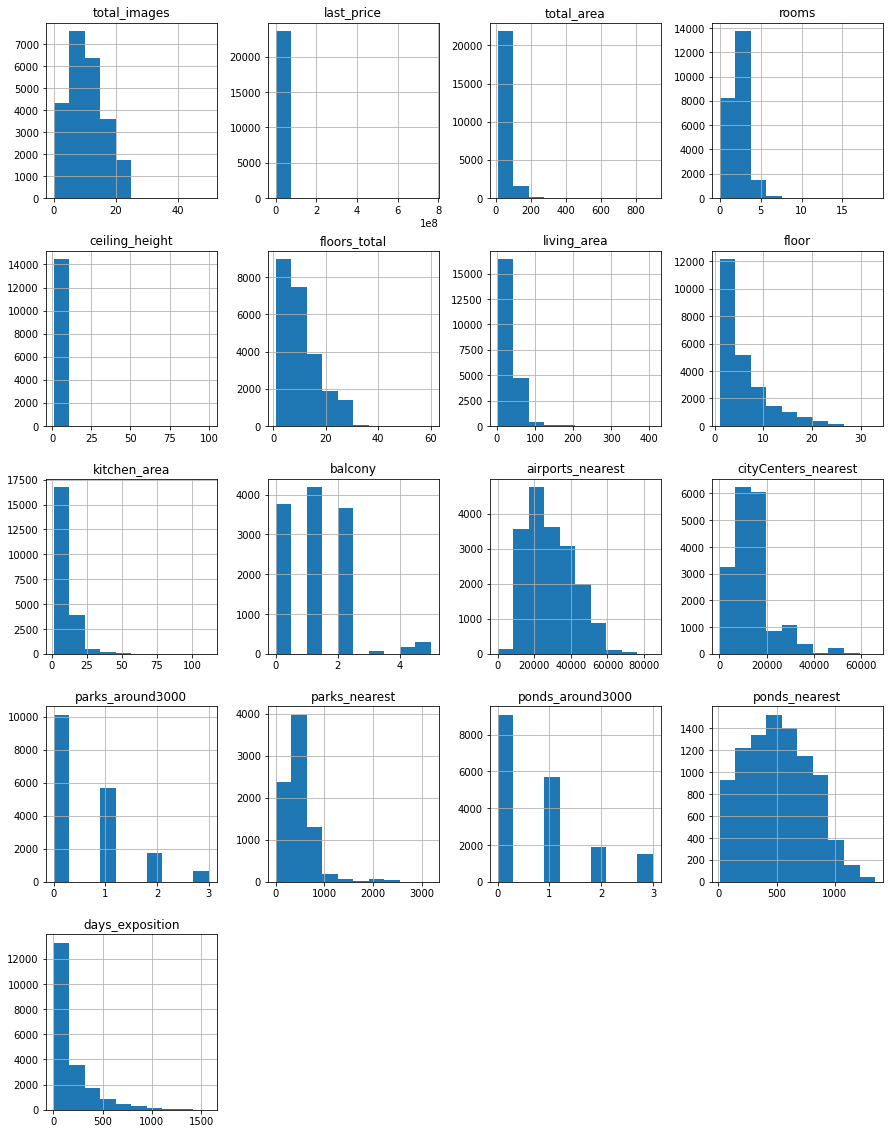

In [1]:
import matplotlib.pyplot as plt
import pandas as pd
try:
    data = pd.read_csv('/datasets/real_estate_data.csv', sep = '\t')
except:
    data = pd.read_csv('https://code.s3.yandex.net/datasets/real_estate_data.csv', sep = '\t')


data.hist(figsize=(15, 20))
data.info()

In [2]:
data.head()

,total_images,last_price,total_area,first_day_exposition,rooms,ceiling_height,floors_total,living_area,floor,is_apartment,...,kitchen_area,balcony,locality_name,airports_nearest,cityCenters_nearest,parks_around3000,parks_nearest,ponds_around3000,ponds_nearest,days_exposition
0,20,13000000.0,108.0,2019-03-07T00:00:00,3,2.70,16.0,51.0,8,NaN,...,25.0,NaN,Санкт-Петербург,18863.0,16028.0,1.0,482.0,2.0,755.0,NaN
1,7,3350000.0,40.4,2018-12-04T00:00:00,1,NaN,11.0,18.6,1,NaN,...,11.0,2.0,посёлок Шушары,12817.0,18603.0,0.0,NaN,0.0,NaN,81.0
2,10,5196000.0,56.0,2015-08-20T00:00:00,2,NaN,5.0,34.3,4,NaN,...,8.3,0.0,Санкт-Петербург,21741.0,13933.0,1.0,90.0,2.0,574.0,558.0
3,0,64900000.0,159.0,2015-07-24T00:00:00,3,NaN,14.0,NaN,9,NaN,...,NaN,0.0,Санкт-Петербург,28098.0,6800.0,2.0,84.0,3.0,234.0,424.0
4,2,10000000.0,100.0,2018-06-19T00:00:00,2,3.03,14.0,32.0,13,NaN,...,41.0,NaN,Санкт-Петербург,31856.0,8098.0,2.0,112.0,1.0,48.0,121.0


### Выполните предобработку данных

In [3]:
data.isna().sum()

total_images                0
last_price                  0
total_area                  0
first_day_exposition        0
rooms                       0
ceiling_height           9195
floors_total               86
living_area              1903
floor                       0
is_apartment            20924
studio                      0
open_plan                   0
kitchen_area             2278
balcony                 11519
locality_name              49
airports_nearest         5542
cityCenters_nearest      5519
parks_around3000         5518
parks_nearest           15620
ponds_around3000         5518
ponds_nearest           14589
days_exposition          3181
dtype: int64

Пропусками в столбцах 'locality_name' и 'floors_total' можно пренебречь.

В столбцах "is_apartment","balcony", "parks_around3000", "ponds_around3000" пропуск означает отсутствие

In [4]:
data['locality_name'] = data['locality_name'].str.replace('ё', 'е').replace(['городской поселок ', 'поселок городского типа ','поселок ','деревня ','село ','садовое товарищество ','садоводческое некоммерческое товарищество '],'', regex=True)
print(data['locality_name'].unique())

['Санкт-Петербург' 'Шушары' 'Янино-1' 'Парголово' 'Мурино' 'Ломоносов'
 'Сертолово' 'Петергоф' 'Пушкин' 'Кудрово' 'Коммунар' 'Колпино'
 'Красный Бор' 'Гатчина' 'Федоровское' 'Выборг' 'Кронштадт' 'Кировск'
 'Новое Девяткино' 'Металлострой' 'Лебяжье' 'Сиверский' 'Молодцово'
 'Кузьмоловский' 'Новая Ропша' 'Павловск' 'Пикколово' 'Всеволожск'
 'Волхов' 'Кингисепп' 'Приозерск' 'Сестрорецк' 'Куттузи' 'Аннино'
 'Ефимовский' 'Плодовое' 'Заклинье' 'Торковичи' 'Первомайское'
 'Красное Село' 'Понтонный' 'Сясьстрой' 'Старая' 'Лесколово' 'Новый Свет'
 'Сланцы' 'Путилово' 'Ивангород' 'Шлиссельбург' 'Никольское' 'Зеленогорск'
 'Сосновый Бор' 'Оржицы' 'Кальтино' 'Романовка' 'Бугры' 'Рощино' 'Кириши'
 'Луга' 'Волосово' 'Отрадное' 'Павлово' 'Оредеж' 'Копорье' 'Молодежное'
 'Тихвин' 'Победа' 'Нурма' 'Синявино' 'Тосно' 'Стрельна' 'Бокситогорск'
 'Александровская' 'Лопухинка' 'Пикалево' 'Терволово' 'Советский'
 'Подпорожье' 'Петровское' 'Токсово' 'Сельцо' 'Вырица' 'Кипень' 'Келози'
 'Вартемяги' 'Тельмана' '

In [5]:
data.duplicated().sum()

0

In [6]:
data['balcony'] = data['balcony'].fillna(0)
data['parks_around3000'] = data['parks_around3000'].fillna(0)
data['ponds_around3000'] = data['ponds_around3000'].fillna(0)
for t in data['rooms'].unique():
    data.loc[(data['rooms'] == t) & (data['living_area'].isna()), 'living_area'] = data.loc[(data['rooms'] == t), 'living_area'].median()
for i in data['rooms'].unique():
    data.loc[(data['rooms'] == i) & (data['kitchen_area'].isna()), 'kitchen_area'] = data.loc[(data['rooms'] == i), 'kitchen_area'].median()

#print(data['ceiling_height'].unique())
data.loc[data['ceiling_height']>9,'ceiling_height'] /=10
data['ceiling_height'] = data['ceiling_height'].fillna(data['ceiling_height'].mean())

data['first_day_exposition'] = pd.to_datetime(data['first_day_exposition'], format='%Y-%m-%dT%H:%M:%S')
data['is_apartment'] = data['is_apartment'].astype(bool)
data['balcony'] = data['balcony'].astype(int)
data['parks_around3000'] = data['parks_around3000'].astype(int)
data['ponds_around3000'] = data['ponds_around3000'].astype(int)


/opt/conda/lib/python3.9/site-packages/numpy/lib/nanfunctions.py:1117: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)


'first_day_exposition' - там храниться дата, был тип объект, стал типом дататайм.

'is_apartment' - столбец с булевым значением, является ли крартира апартаментами.

'balcony' - не может быть 2.5 балкона, поэтому тип int.

'parks_around3000', 'ponds_around3000' - кол-во парков и водоемов как и балконов, для оптимизации таблицы стали типом int

### Добавьте в таблицу новые столбцы

In [7]:
data['metr'] = round(data['last_price']/data['total_area'], 2)
data['weekday'] = data['first_day_exposition'].dt.dayofweek
data['month'] = pd.DatetimeIndex(data['first_day_exposition']).month
data['year'] = pd.DatetimeIndex(data['first_day_exposition']).year

data.loc[data['floor'] == 1,'floors'] = "Первый"
data.loc[data['floor'] == data['floors_total'],'floors'] = "Последний"
data['floors'] = data['floors'].fillna('Другой')

data['cityCenters_km'] = round(data['cityCenters_nearest']/1000)
print(data.head())

   total_images  last_price  total_area first_day_exposition  rooms  \
0            20  13000000.0       108.0           2019-03-07      3   
1             7   3350000.0        40.4           2018-12-04      1   
2            10   5196000.0        56.0           2015-08-20      2   
3             0  64900000.0       159.0           2015-07-24      3   
4             2  10000000.0       100.0           2018-06-19      2   

   ceiling_height  floors_total  living_area  floor  is_apartment  ...  \
0          2.7000          16.0         51.0      8          True  ...   
1          2.7281          11.0         18.6      1          True  ...   
2          2.7281           5.0         34.3      4          True  ...   
3          2.7281          14.0         45.0      9          True  ...   
4          3.0300          14.0         32.0     13          True  ...   

   parks_nearest  ponds_around3000  ponds_nearest  days_exposition       metr  \
0          482.0                 2          755

### Проведите исследовательский анализ данных

<AxesSubplot:xlabel='name'>

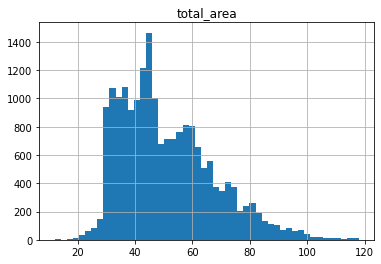

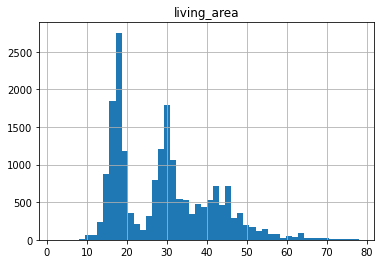

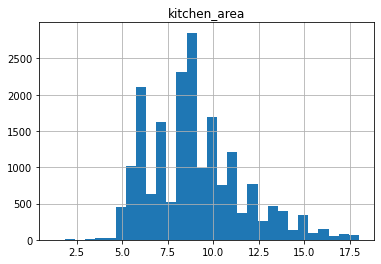

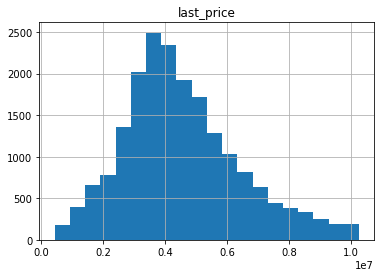

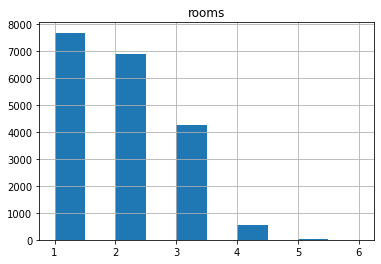

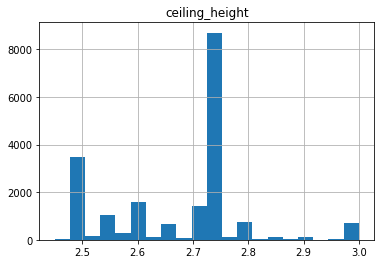

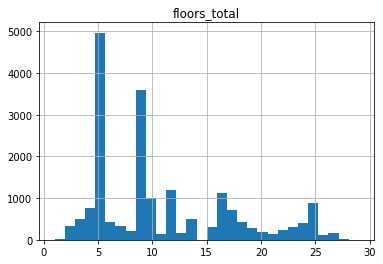

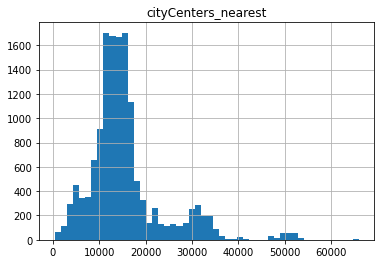

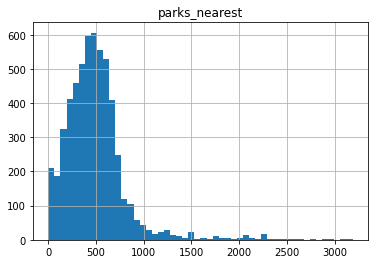

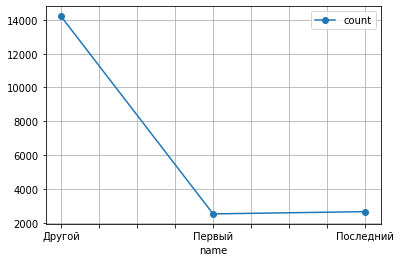

In [8]:
# plt.ylim(-10, 200)
#data.boxplot('total_area')
data = data.query('total_area<=118')

# plt.ylim(0, 50)
# data.boxplot('kitchen_area')
data = data.query('kitchen_area<=18')

# plt.ylim(-10, 80)
# data.boxplot('living_area')
data = data.query('living_area<=79')

# plt.ylim(-1000, 11000000)
# data.boxplot('last_price')
data = data.query('last_price<=10250000')

# plt.ylim(-10, 30)
# data.boxplot('floors_total')
data = data.query('floors_total<=29')

# plt.ylim(-3000, 30000)
# data.boxplot('cityCenters_nearest')
#    data = data.query('cityCenters_nearest<=25500')

# plt.ylim(-100, 1200)
# data.boxplot('parks_nearest')
#  data = data.query('parks_nearest<=1090')

# plt.ylim(2.4, 3)
# data.boxplot('ceiling_height')
data = data.query('2.45<=ceiling_height<=3').reset_index(drop = True)


data.hist('total_area',bins=50)
data.hist('living_area',bins=50)
data.hist('kitchen_area',bins=30)
data.hist('last_price',bins=20)
data.hist('rooms',bins=10)
data.hist('ceiling_height',bins=20)
data.hist('floors_total',bins=30)
data.hist('cityCenters_nearest',bins=50)
data.hist('parks_nearest',bins=50)

floors = pd.DataFrame({
    'name': ['Другой','Первый','Последний'],
    'count': [14211,2534,2666]
})
floors.plot(x='name', y='count', style='-o', grid=True)
#print(data['rooms'].unique())
#print(data.groupby('floors')['floors'].count())

В колонке общей площади начинаются выбросы после 118 кв.м.

В колонке жилой площади начинаются выбросы после 79 кв.м.

В колонке площади кухни начинаются выбросы после 18 кв.м.

В колонке цены начинаются выбросы после 10 250 000

В колонке кол-ва этажей начинаются выбросы после 29

В колонке Высота потолков аномальные значения до 2.45м и после 3м


mean      168.716967
median     89.000000
Name: days_exposition, dtype: float64


<AxesSubplot:>

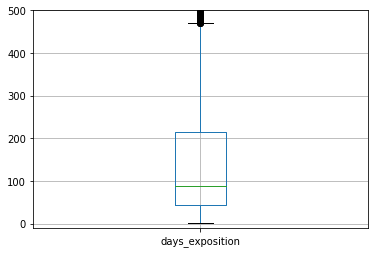

In [9]:
pivot_table = data['days_exposition'].agg(['mean','median'])
data.hist('days_exposition',bins=50)
print(pivot_table)
#plt.ylim(-10, 500)
#data.boxplot('days_exposition')

Обычно продажа занимает от 0 дней (то есть купили в день размещения объявления) до 1500 дней

В среднем продажа занимает около 90 дня

Быстрой продажа считается меньше 50 дней

Необычайно долгой больше 470 дней

Общая площадь 0.6458735213738944
Жилая площадь 0.5076426036050293
Площадь кухни 0.42768692971610917
Комнаты 0.40528266460751033


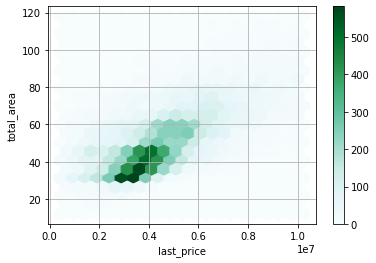

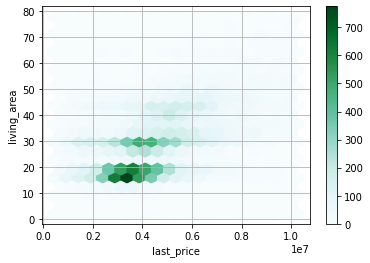

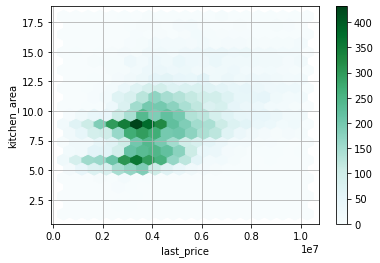

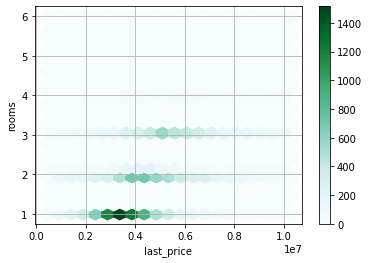

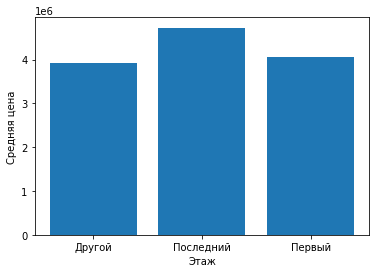

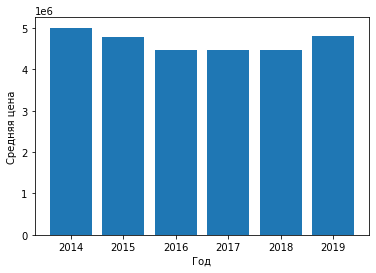

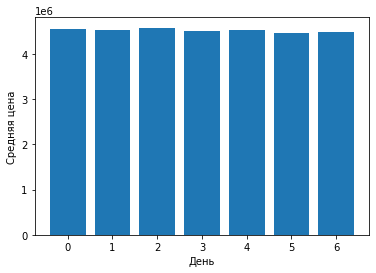

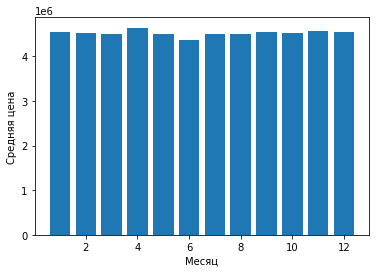

In [10]:
zavisimost1 = []
zavisimost = pd.DataFrame({
    'name': ['Другой', 'Последний', 'Первый']
})
for d in data['floors'].unique():
    a = data[data['floors'] == d]['last_price'].mean()
    try:
        zavisimost1.append(a)
    except Exception as e:
        print(e)
        zavisimost1.append(a)
zavisimost['mean'] = zavisimost1

for t in data['year'].unique():
    data.loc[(data['year'] == t), 'year_sr'] = \
    data.loc[(data['year'] == t), 'last_price'].mean()
for t in data['weekday'].unique():
    data.loc[(data['weekday'] == t), 'weekday_sr'] = \
    data.loc[(data['weekday'] == t), 'last_price'].mean()
for t in data['month'].unique():
    data.loc[(data['month'] == t), 'month_sr'] = \
    data.loc[(data['month'] == t), 'last_price'].mean()

print('Общая площадь',data['last_price'].corr(data['total_area']))
print('Жилая площадь',data['last_price'].corr(data['living_area']))
print('Площадь кухни',data['last_price'].corr(data['kitchen_area']))
print('Комнаты',data['last_price'].corr(data['rooms']))

data.plot(x='last_price', y='total_area', kind='hexbin', gridsize=20, grid=True, sharex=False)
data.plot(x='last_price', y='living_area', kind='hexbin', gridsize=20, grid=True, sharex=False)
data.plot(x='last_price', y='kitchen_area', kind='hexbin', gridsize=20, grid=True, sharex=False)
data.plot(x='last_price', y='rooms', kind='hexbin', gridsize=20, grid=True, sharex=False)

plt.figure(figsize=(6, 4))
plt.bar(zavisimost['name'],zavisimost['mean'])
plt.xlabel('Этаж')
plt.ylabel('Средняя цена')
plt.show()
plt.figure(figsize=(6, 4))
plt.bar(data['year'],data['year_sr'])
plt.xlabel('Год')
plt.ylabel('Средняя цена')
plt.show()
plt.figure(figsize=(6, 4))
plt.bar(data['weekday'],data['weekday_sr'])
plt.xlabel('День')
plt.ylabel('Средняя цена')
plt.show()
plt.figure(figsize=(6, 4))
plt.bar(data['month'],data['month_sr'])
plt.xlabel('Месяц')
plt.ylabel('Средняя цена')
plt.show()

**Наибольшая корреляция у параметра "Общая площадь", но также она есть и у параметров "Жилая площадь" и "Площадь кухни", а также есть слабая связь с параметром "кол-во комнат"**

In [15]:
data_metr = data.groupby('locality_name').agg(
    kol=('last_price', 'size'),
    mean_price=('metr', 'mean')
).sort_values(by = 'kol',ascending = False).reset_index()
data_metr = data_metr[:10]
print(data_metr.to_string(formatters={'mean_price':'{:.7}'.format}))
print()
print("Самый дорогой метр")
print(data_metr[data_metr['mean_price'] == data_metr['mean_price'].max()])
print()
print("Самый дешевый метр")
print(data_metr[data_metr['mean_price'] == data_metr['mean_price'].min()])

     locality_name    kol mean_price
0  Санкт-Петербург  11959   103939.6
1           Мурино    543   85706.66
2           Шушары    426   78188.94
3          Кудрово    413   95171.58
4       Всеволожск    373   66634.69
5          Колпино    319   75304.96
6        Парголово    313   90784.24
7           Пушкин    309   99665.45
8          Гатчина    296   68527.67
9           Выборг    211   57849.49

Самый дорогой метр
     locality_name    kol     mean_price
0  Санкт-Петербург  11959  103939.624051

Самый дешевый метр
  locality_name  kol    mean_price
9        Выборг  211  57849.490427


    cityCenters_km      price
0              0.0 6466666.67
1              1.0 7344877.53
2              2.0 7309965.52
3              3.0 6447875.22
4              4.0 6876684.16
5              5.0 6866563.97
6              6.0 6499474.79
7              7.0 6110300.97
8              8.0 6000705.36
9              9.0 5222318.95
10            10.0  5089174.0
11            11.0 5086491.12
12            12.0 5138717.04
13            13.0 5312366.36
14            14.0 5146173.93
15            15.0 5106836.32
16            16.0 4955486.64
17            17.0 4747770.37
18            18.0 4573251.95
19            19.0 4798737.95
20            20.0 4611578.95
21            21.0  5308405.1
22            22.0 5099756.29
23            23.0 4634392.41
24            24.0  3890686.8
25            25.0 4000993.25
26            26.0 4015222.45
27            27.0  2250000.0
28            28.0 5026428.57
29            29.0  4092500.0


<AxesSubplot:xlabel='cityCenters_km'>

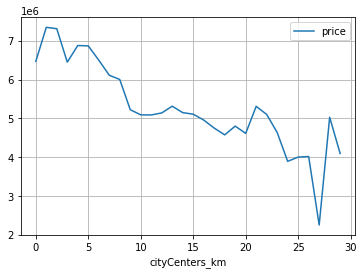

In [16]:
data_piter = data[data['locality_name']== 'Санкт-Петербург']
data_piter = data_piter.groupby('cityCenters_km').agg(
    price =('last_price', 'mean')
).sort_values(by = 'cityCenters_km').reset_index()
print(data_piter.to_string(formatters={'price':'{:.9}'.format}))
data_piter.plot(x='cityCenters_km', y='price', grid=True)

Чем дальшше от центра тем дешевле жильё  
С 20км встречаются дорогое жилье в пригородных районах

### Oбщий вывод

**Согласно проведенному исследованию, я получил следующие результаты:**  
- Продажа квартиры занимает в среднем около 90 дня  
    Быстрой продажа считается меньше 50 дней,  
    Необычайно долгой больше 470 дней
- Цена квартиры чаще всего зависит от следующих параметров:  
В большей степени цена зависит от Общей площади квартиры, Жилой площади и Площади кухни  
В меньшей степени от Количества комнат и Года публикования объявления  
- Люди предпочтительнее прокупают квартиры на промежуточных этажах (не на первом и не на последнем этаже)
- С 2014 года недвижимость начала снижаться в цене, а с 2016 года начала рости
- Среди топ-10 по количеству объявлений первое место занимает Питер, и в этом городе самый дорогой квадратный метр  
В этом же топе самый дешевый квадратный метр принадлежит Выборгу
- Так же есть тенденция, чем дальше от центра города тем дешевле жилплощадь (исключения состовляет загородное жильё в элитном районе)
